In [2]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from scipy.integrate import dblquad, tplquad, trapezoid
from src.simulations.MonteCarlo import MonteCarloSimulation
from src.simulations.Rebound import OrbitalSimulation
from numpy.random import SeedSequence, Generator, PCG64
import src.utils.calculations as calc
import multiprocessing
import datetime
from numpy.random import SeedSequence, Generator, PCG64
import src.simulations.MonteCarlo_impsamp as mc_imp
import src.configurations.Configuration as conf
import src.analysis.Analysis as anl
import src.plotting.Plotting as pl

Using REPO_ROOT: /data/a.saricaoglu/repo/captus


SyntaxError: duplicate argument 'fig_size' in function definition (Plotting.py, line 1601)

In [3]:
G = const.G.value
name = "IntBH_Star"
m_Sun = const.M_sun.value
m_Jup =  const.M_jup.value  # Mass of Jupiter
print(f'Mass of Jupiter: {m_Jup} kg')
print(f'Mass of Sun: {m_Sun} kg')
m_Neptune = 5.15*10**-5 * const.M_sun.value  # Mass of Neptune
m_PBH = 1e-13 * const.M_sun.value
print(f'Mass of PBH: {m_PBH} kg')
r_SJ = (5.2*u.au).to(u.m).value
r_SN = (30.07*u.au).to(u.m).value
v_Jup = 13.06 * 1e3  # km/s to m/s
v_Neptune = 5.45 * 1e3  # km/s to m/s
epsilon = 0.1
v_inf = 20.23 * 1e3  # km/s to m/s
r_jupiter = const.R_jup.to(u.m).value
r_neptune = 24622 * 1e3  # in meters
r_sun = const.R_sun.to(u.m).value
e_jupiter = 0.0489
i_jupiter = 1.304 * (np.pi/180)
A_jupiter = np.pi * r_jupiter**2
aB = r_SJ
rA = r_sun
rB = r_jupiter
mA = m_Sun
mB = m_Jup
mC = m_PBH
muA = G * mA
muB = G * mB
vBMag = v_Jup
# seed = 42
# system_param_dict = {
#     'name': name,
#     'mA': m_Sun,
#     'mB': m_Jup,
#     'mC' : mC,
#     'aB': aB,
#     'rB': rB,
#     'vB' : vBMag,
#     'eB' : e_jupiter,
#     'iB' : i_jupiter,
#     'epsilon': epsilon,
#     'seed_base': seed,
# }

# trials = 10_000_000
# sample_size = 200
# lambda_limits = [0, 2*np.pi]
# cosbeta_limits = [-1, 1]   # cosβ
# phi_limits = [0, 2 * np.pi]

# r_hill = calc.hill_radius(aB, mA, mB, e_jupiter)
# vesc = calc.v_esc(muA, aB)
# rclose = calc.r_close(epsilon, mA, mB, aB)
# vmax = vesc + 2*vBMag
# vinf_max = np.sqrt(vmax**2 - (2 * muA / aB) - (2 * muB / rclose))
# v_inf_grid = np.linspace(1e3, (544e3), 20) # from 1 km/s to 800 km/s, Maximum incoming velocity v_max: 40498.00358610428

# print(f'orbital velocity of B: {vBMag}')
# print("Escape velocity v_esc:", vesc)
# print("Maximum incoming velocity v_max:", vinf_max)
# T =2*np.pi*np.sqrt(aB**3/(G*(mA + mB)))
# print(f'Orbital period of B: {T/(3600*24)} days')
# print(f'Semimajor axis of B: {aB*u.m.to(u.au)} au')
# print(f'radius of B: {rB*u.m.to(u.au)} au')
# print(f'rclose: {rclose*u.m.to(u.au)} au')
# print(f'rhill: {r_hill*u.m.to(u.au)} au')
# print(f'rjup: {const.R_jup.to(u.au)} au')
# print(f'rclose/rhill: {rclose/r_hill}')
# print(f'radius of C: {calc.schwarzchild_radius(mC)*u.m.to(u.au)} au')
# print(system_param_dict)

Mass of Jupiter: 1.8981245973360505e+27 kg
Mass of Sun: 1.988409870698051e+30 kg
Mass of PBH: 1.988409870698051e+17 kg


In [23]:
s = datetime.datetime.now()
G = const.G.value

name = "CygnusX1"
m_Sun = const.M_sun.value
m_Jup = const.M_jup.value
r_Sun = const.R_sun.value
rC_rH_ratio = 0.7040
mA = m_Sun * 8200
mB = m_Sun *10
mC = m_Sun * 0.1
rA = calc.schwarzchild_radius(mA)
rB = 5 * r_Sun
muA = G * mA
muB = G * mB
opB = 62043  # days
aB = calc.semimajor_axis(opB*24*3600, mA, mB)
vBMag = (133e3 + 87e3)/2  # in m/s
iB = 0 # in radians
eB = 0.2
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
seed = 42
system_param_dict = {
    'name': name,
    'mA': mA,
    'mB': mB,
    'mC' : mC,
    'aB': aB,
    'rB': rB,
    'vB' : vBMag,
    'eB' : eB,
    'iB' : iB,
    'epsilon': epsilon,
    'seed_base': seed,
}

trials = 1_000_000_000
sample_size = 200
lambda_limits = [0, 2*np.pi]
cosbeta_limits = [-1, 1]   # cosβ
phi_limits = [0, 2 * np.pi]

vesc = calc.v_esc(muA, aB)
rclose = calc.r_close(epsilon, mA, mB, aB)
vmax = vesc + 2*vBMag
vinf_max = np.sqrt(vmax**2 - (2 * muA / aB) - (2 * muB / rclose))
v_inf_grid = np.linspace(1e3, (544e3), 20) # from 1 km/s to 800 km/s, Maximum incoming velocity v_max: 40498.00358610428

print(f'orbital velocity of B: {vBMag}')
print("Escape velocity v_esc:", vesc)
print("Maximum incoming velocity v_max:", vinf_max)
T =2*np.pi*np.sqrt(aB**3/(G*(mA + mB)))
print(f'Orbital period of B: {T/(3600*24)} days')
print(f'Semimajor axis of B: {aB*u.m.to(u.au)} au')
print(f'radius of B: {rB*u.m.to(u.au)} au')
print(f'rclose: {rclose*u.m.to(u.au)} au')
print(f'rhill: {r_hill*u.m.to(u.au)} au')
print(f'rjup: {const.R_jup.to(u.au)} au')
print(f'rclose/rhill: {rclose/r_hill}')
print(f'radius of C: {calc.schwarzchild_radius(mC)*u.m.to(u.au)} au')
print(system_param_dict)

orbital velocity of B: 110000.0
Escape velocity v_esc: 153341.50498225144
Maximum incoming velocity v_max: 339385.7241701074
Orbital period of B: 62042.99999999985 days
Semimajor axis of B: 618.7434681881534 au
radius of B: 0.023252336304810786 au
rclose: 25.803887284463443 au
rhill: 36.65324898361283 au
rjup: 0.0004778945025452157 AU au
rclose/rhill: 0.7040000000000002
radius of C: 1.9741257427538035e-09 au
{'name': 'CygnusX1', 'mA': np.float64(1.6304960939724018e+34), 'mB': np.float64(1.988409870698051e+31), 'mC': np.float64(1.988409870698051e+29), 'aB': np.float64(92562705350480.95), 'rB': np.float64(3478500000.0), 'vB': 110000.0, 'eB': 0.2, 'iB': 0, 'epsilon': np.float64(0.05947540101248887), 'seed_base': 42}


In [4]:
name = "IntermediateBH_Star_new"
seed = 42
configuration = conf.Configuration(name=name, seed=seed, importance_sampling=True, config_file=None)
sd = configuration.get_system_param(all=True)
sp = configuration.get_simulation_param(all=True)
print(sp['trials'])
configuration.print_preview()
configuration.print_configuration()

10000000
Configuration Preview:
  Name: IntermediateBH_Star_new
  Seed: 42
Orbital velocity of B: 2825623.96763961 m/s
Escape velocity v_esc: 3996035.7372024124 m/s
Maximum incoming velocity v_max: 8772306.362057041 m/s
Orbital period of B: 153.98230738633993 days
Semimajor axis of B: 40.0 au
Radius of B: 1.1440149461966906 au
rClose: 1.3149565420674616 au
rHill: 1.8678359972549168 au
rClose/rHill: 0.7040000000000001
Radius of C: 1.9741257427538034e-08 au
System Parameters:
  mA: 7.158275534512984e+35
  mB: 2.187250857767856e+32
  mC: 1.988409870698051e+30
  aB: 5983914828000.0
  rB: 171142200000.0
  vB: 2825623.96763961
  eB: 0
  iB: 0
  epsilon: 0.11626902801921635
  seed_base: 42
  name: IntermediateBH_Star_new

Simulation Parameters:
  trials: 10000000
  max_trials: 1000000000
  sample_size: 200
  max_e: 1.0
  vDM: 220000.0
  v_inf_grid: [  1000.          29578.94736842  58157.89473684  86736.84210526
 115315.78947368 143894.73684211 172473.68421053 201052.63157895
 229631.57894737

In [5]:
# def mc_worker(pars):
#     conf, child_ss, v_inf = pars
#     rng = Generator(PCG64(child_ss)) # independent per worker
#     simulation = mc_imp.MonteCarloSimulation(conf, rng)
#     return simulation.run_monte_carlo_simulation(v_inf)

# s = datetime.datetime.now()
# if __name__ == "__main__":

#     base_ss = SeedSequence(seed)
#     v_inf_grid = configuration.get_simulation_param('v_inf_grid')
#     child_sss = base_ss.spawn(len(v_inf_grid))
#     pars = [(configuration, child_sss[i], v_inf_grid[i]) for i in range(len(v_inf_grid))]
#     # Create a pool of workers
#     num_cores = len(v_inf_grid)  # Get the number of available CPU cores
#     with multiprocessing.Pool(processes=num_cores) as pool:
#         # Distribute the simulations across the cores
#         results = pool.map(mc_worker, pars)
#     pool.close()
#     pool.join()

#     print(f'Execution time: {datetime.datetime.now() - s} for {len(v_inf_grid)} simulations')

In [6]:

analysis = anl.Analysis(name=name, configuration=configuration, results_dir_rebound='/data/a.saricaoglu/repo/captus/runs/IntermediateBH_Star/Rebound_Simulation_Results')
cat = analysis.get_combined_dictionary()
mc = analysis.get_mc_results()

Loading MC results from: /data/a.saricaoglu/repo/captus/runs/IntermediateBH_Star_new/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/IntermediateBH_Star/Rebound_Simulation_Results
captured objects for v_inf = v1 km/s: 200
v_inf = v1 km/s: sampled 200 captured objects
captured objects for v_inf = v144 km/s: 200
v_inf = v144 km/s: sampled 200 captured objects
captured objects for v_inf = v115 km/s: 200
v_inf = v115 km/s: sampled 200 captured objects
captured objects for v_inf = v58 km/s: 200
v_inf = v58 km/s: sampled 200 captured objects
captured objects for v_inf = v315 km/s: 200
v_inf = v315 km/s: sampled 200 captured objects
captured objects for v_inf = v30 km/s: 200
v_inf = v30 km/s: sampled 200 captured objects
captured objects for v_inf = v87 km/s: 200
v_inf = v87 km/s: sampled 200 captured objects
captured objects for v_inf = v230 km/s: 200
v_inf = v230 km/s: sampled 200 captured objects
captured objects for v_inf = v287 km/s: 200
v_inf = v28

In [7]:
for v in mc.keys():
    print(np.max(mc[v]['e']))


0.9967733769475615
0.9997851603468866
0.9986838250539133
0.9990402200719969
0.9984284625419753
0.9960946662069553
0.9997855982963264
0.9978368768842928
0.998201361360598
0.9988836240887753
0.9973479655327333
0.9972594047618666
0.9984421849334978
0.9983646426540996
0.9970811602558981
0.9961498185688514
0.9981956073118429
0.9971540199136363
0.9987289050873156
0.9985382853170747


In [8]:
analysis.print_detailed_catalog_summary()

Velocity bin: v1, sampled capture count 200 total capture count: 200 out of 8809 samples
v1 non-zero termination counts:
  b_err_count: 9
  escape_C_count: 105
  time_exceeded_count: 1
  collision_count: 94
--------------------------------
Velocity bin: v30, sampled capture count 200 total capture count: 200 out of 9852 samples
v30 non-zero termination counts:
  b_err_count: 10
  escape_C_count: 109
  time_exceeded_count: 2
  collision_count: 89
--------------------------------
Velocity bin: v58, sampled capture count 200 total capture count: 200 out of 9803 samples
v58 non-zero termination counts:
  b_err_count: 9
  escape_C_count: 111
  time_exceeded_count: 4
  collision_count: 85
--------------------------------
Velocity bin: v87, sampled capture count 200 total capture count: 200 out of 10187 samples
v87 non-zero termination counts:
  b_err_count: 12
  P_err_count: 1
  escape_C_count: 115
  time_exceeded_count: 1
  collision_count: 84
--------------------------------
Velocity bin: 

In [9]:
analysis.print_occurrences_summary()

Occurrences summary:
Velocity bin: v1, captured count: 200
    n_sampled: 8809
    n_sampled_captures: 200
    n_ejected: 105
    n_collided: 94
    n_terminated: 199
    capture_cross_section_total: 0.12333208073577435
    capture_cross_section_ejected: 0.06474934238628154
    capture_cross_section_collided: 0.057966077945813946
    capture_cross_section_terminated: 0.12271542033209548
    capture_cross_section_total_areaB: 0.029995961604382712
    ejection_rate: 1.9747603061948776e-06
    collision_rate: 7.023353317065169e-06
    termination_rate: 2.990011401493647e-06
    total_rate: 2.8260268490841375e-06
    terminated_systems_neq: 12.346168969728291
    ejected_systems_neq: 9.863405644922354
    collided_systems_neq: 2.4827633248059344
    total_systems_neq: 13.128215481546242
    average_lifetime_ejected: 506390.57148504164
    average_lifetime_collided: 142382.12928434412
    average_lifetime_terminated: 334446.88521938556
    average_lifetime_total: 353853.67988420965
--------

In [10]:
cat = analysis.get_combined_dictionary()
print(cat['total_occurrences_trapz'])
print(cat['total_occurrences_gl'])


{'total_captured': 4000, 'total_sampled': 569220, 'total_ejected': 2311, 'total_collided': 1655, 'total_terminated': 3966, 'terminated_systems_neq': np.float64(11799809.387387814), 'ejected_systems_neq': np.float64(9403888.838925384), 'collided_systems_neq': np.float64(2395920.5484624323), 'total_systems_neq': np.float64(13319314.445337726)}
{'total_systems_neq_gl': np.float64(13148743.41918678), 'collided_systems_neq_gl': np.float64(2329828.3900798126), 'ejected_systems_neq_gl': np.float64(9211664.154333303), 'terminated_systems_neq_gl': np.float64(11541492.544413116), 'v_bins_used': 20}


In [9]:
# for v in cat.keys():
#     d = cat[v]['rebound']
#     lifetimes = [e["lifetime"] for e in d if "lifetime" in e.files]
#     print(np.mean(lifetimes), np.median(lifetimes))
#     # print(f'v_inf: {v/1e3} km/s, lifetimes (Myr): {[lt/1e6 for lt in lifetimes]}')

In [10]:
# # ...existing code...
# import numpy as np
# import matplotlib.pyplot as plt

# # 1) Collect all unique v_keys sorted by speed and all time arrays
# sorted_vkeys = sorted(cat.keys(), key=lambda k: int(k[1:]) if k.startswith('v') else 1e9)
# v_infs_kms = []
# time_arrays = []
# per_v_entries = []

# for vk in sorted_vkeys[:-1]:
#     rb_list = cat[vk]['rebound']
#     mc = cat[vk]['mc']
#     if mc is None or not rb_list:
#         continue
#     v_infs_kms.append(mc['v_inf'] / 1e3)
#     per_v_entries.append(rb_list)
#     # gather times from entries that have them
#     for e in rb_list:
#         data = e.get('data', e)
#         if hasattr(data, 'files') and 'times' in data.files:
#             time_arrays.append(np.asarray(data['times']))

# # 2) Build a common time grid (union range, choose N bins)
# if len(time_arrays) == 0:
#     raise RuntimeError("No time arrays found in rebound entries.")
# t_min = min(arr.min() for arr in time_arrays if arr.size)
# t_max = max(arr.max() for arr in time_arrays if arr.size)
# N_time = 200  # choose resolution
# t_grid = np.linspace(t_min, t_max, N_time)

# # 3) Build the cube: [n_v, n_systems(v), n_time] via interpolation
# # Then reduce to 2D [n_v, n_time] by nanmedian across systems
# median_a_matrix = []
# for rb_list in per_v_entries:
#     # collect per-system series interpolated onto t_grid
#     series_interp_list = []
#     for e in rb_list:
#         data = e.get('data', e)
#         if not hasattr(data, 'files'):
#             continue
#         if ('times' in data.files) and ('semi_major_axes' in data.files):
#             t = np.asarray(data['times'])
#             y = np.asarray(data['semi_major_axes'])
#             # filter finite and monotonic time segments
#             mask = np.isfinite(t) & np.isfinite(y)
#             t_f = t[mask]
#             y_f = y[mask]
#             if t_f.size < 2:
#                 continue
#             # ensure increasing time for interpolation
#             order = np.argsort(t_f)
#             t_f = t_f[order]
#             y_f = y_f[order]
#             # interpolate; outside range -> NaN
#             yi = np.interp(t_grid, t_f, y_f, left=np.nan, right=np.nan)
#             series_interp_list.append(yi)
#     if len(series_interp_list) == 0:
#         # no valid series for this v_key; fill NaNs
#         median_a = np.full_like(t_grid, np.nan, dtype=float)
#     else:
#         cube_v = np.vstack(series_interp_list)              # shape (n_sys, N_time)
#         median_a = np.nanmedian(cube_v, axis=0)             # shape (N_time,)
#     median_a_matrix.append(median_a)

# median_a_matrix = np.vstack(median_a_matrix)                # shape (n_v, N_time)
# v_infs_kms = np.asarray(v_infs_kms)

# # 4) Plot heatmap (v vs time) using imshow
# plt.figure(figsize=(7, 5))
# # extent: [t_min, t_max, v_min, v_max]; origin lower to match increasing v
# plt.imshow(median_a_matrix,
#            extent=[t_grid.min(), t_grid.max(), v_infs_kms.min(), v_infs_kms.max()],
#            aspect='auto',
#            origin='lower',
#            cmap='viridis')
# plt.xlabel("time [yr]")
# plt.ylabel("v_inf [km/s]")
# cbar = plt.colorbar()
# cbar.set_label("median semi-major axis a [AU]")
# plt.title("Median a(t) vs v_inf")
# plt.show()
# # ...existing code...

In [11]:
# print(cat.items())
# v = cat.get('v1').get('rebound')[0]
# print(v['semi_major_axes'])
# print(v['integrations'])
# print(v['lifetime']*365)
# print(v['orbital_periods']*365)
# x = cat.get('v1').get('rebound')
# print(len(x))
# print([i for i in x[0].keys()])

# metric = [rb_entry['semi_major_axes'] for rb_entry in x if 'semi_major_axes' in rb_entry.files]
# metric2 = [rb_entry['integrations'] for rb_entry in x if 'integrations' in rb_entry.files]
# print(np.shape([]))
# print(np.shape(metric[0]))
# print(np.shape(metric2[0])) 
# print(metric[0].flatten())
# print(metric2[0].flatten())
# print(len(metric.flatten()))
# print(len(metric2.flatten()))
# print(len(metric[0]))
# print(isinstance(metric[0][0], list))
# print((metric[0].any())>0)
# print(isinstance(metric2[0], float))
# print(float(metric2[0]))
# metric = [np.mean(m) for m in metric if len(m) > 0]
# print(len(metric))

# if (metric.any().flatten()) > 0:
#     print("yes")


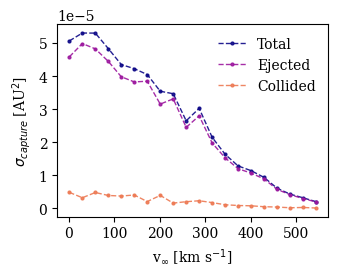

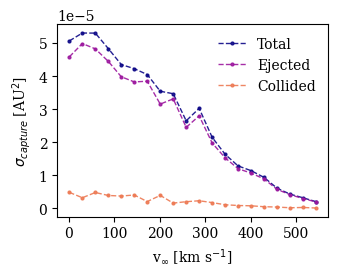

In [21]:
plotobj = pl.Plots(name='cygnus_trial', analysis=[analysis])
mlist0 = ['capture_cross_section_total','capture_cross_section_ejected','capture_cross_section_collided']
mlabels0 = ['Total', 'Ejected', 'Collided']
mylabel0 = r'$\sigma_{capture}$ [AU$^2$]'
plotobj.plot_metric_wrt_v(metric_list=mlist0, metric_ylabel=mylabel0, metric_labels=mlabels0, analysis_name='CygnusX1', save=False)

/data/a.saricaoglu/repo/captus/src/plotting/Plotting.py:214: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(frameon=False, loc='upper center', ncol=2)


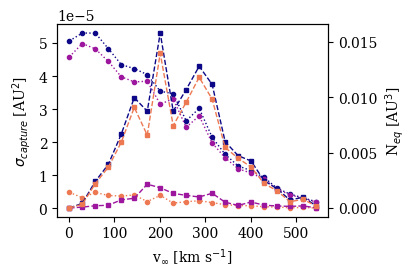

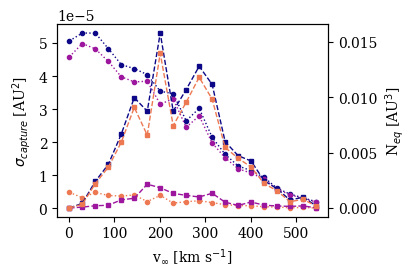

In [22]:
mlist2 = ['total_systems_neq','ejected_systems_neq','collided_systems_neq']
mlabels2 = ['Total', 'Ejected', 'Collided']
mylabel2 =r'N$_{eq}$ [AU$^3$]'
mlists = [mlist0, mlist2]
mlabels = [mlabels0, mlabels2]
mylabels = [mylabel0, mylabel2]
plotobj.plot_metric_wrt_v_twinaxis(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=None, analysis_name='CygnusX1', save=False)

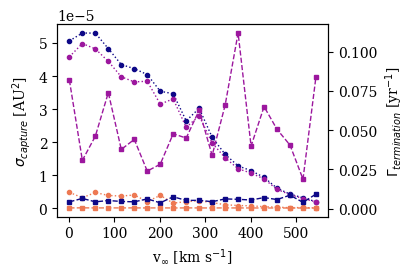

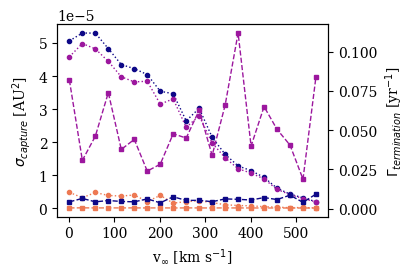

In [23]:
mlist1 = ['total_rate','ejection_rate','collision_rate']
mlabels1 = ['Total', 'Ejected', 'Collided']
mylabel1 =r'$\Gamma_{termination}$ [yr$^{-1}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
plotobj.plot_metric_wrt_v_twinaxis(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=None, analysis_name='CygnusX1', save=False)

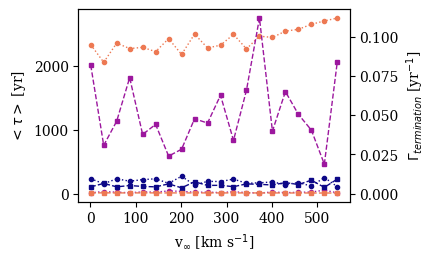

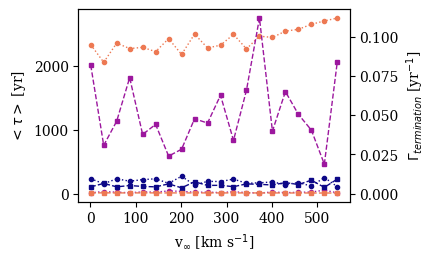

In [12]:
mlist3 = ['average_lifetime_total','average_lifetime_ejected','average_lifetime_collided']
mlabels3 = ['Total', 'Ejected', 'Collided']
mylabel3 =r'$<\tau>$ [yr]'
mlists = [mlist3, mlist1]
mlabels = [mlabels3, mlabels1]
mylabels = [mylabel3, mylabel1]
plotobj.plot_metric_wrt_v_twinaxis(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=None, analysis_name='CygnusX1', save=False)

TypeError: argument of type 'int' is not iterable

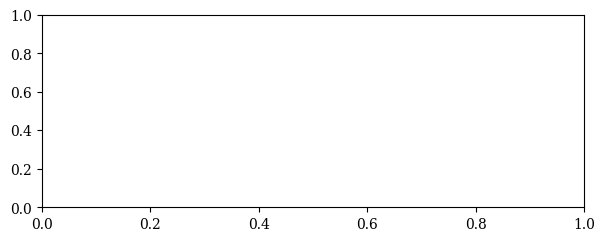

In [13]:
plotobj = pl.Plots(name='cygnus_trial', analysis=[analysis])
mlist0 = ['semi_major_axes', 'semi_major_axes']
masks0 = [None, {"type":"flag_contains","substr":"escape_C"}]  # No mask for semi_major_axes and semimajor_axes
mylabel0 = r'Semi-Major Axis [AU]'
dataset = plotobj.plot_metric_array_wrt_v(metric_list=mlist0, metric_ylabel=mylabel0, metric_masks=masks0, analysis_name='CygnusX1', save=False)

TypeError: argument of type 'int' is not iterable

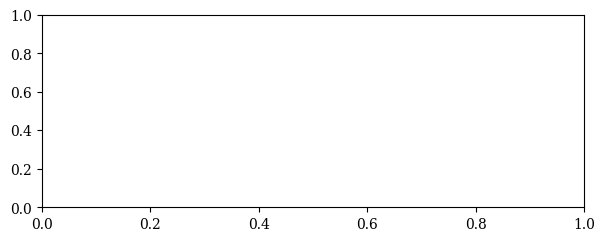

In [14]:
mlist0 = ['semi_major_axes', 'semi_major_axes']
masks0 = [{"type":"collision"}, {"type":"flag_contains","substr":"escape_C"}]  # No mask for semi_major_axes and semimajor_axes
mylabel0 = r'Semi-Major Axis [AU]'
dataset = plotobj.plot_metric_array_wrt_v(metric_list=mlist0, metric_ylabel=mylabel0, metric_masks=masks0, analysis_name='CygnusX1', save=False)

TypeError: argument of type 'int' is not iterable

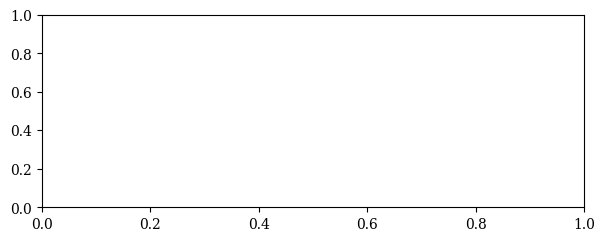

In [15]:
mlist = ['orbital_periods']
mylabel = r'Orbital Period [yr]'
dataset = plotobj.plot_metric_array_wrt_v(metric_list=mlist, metric_ylabel=mylabel, analysis_name='CygnusX1', save=False)

(<Figure size 700x250 with 1 Axes>,
 [[0.04184864653352192,
   0.034536128567566035,
   0.03867088814351206,
   42.9203324213464,
   2376.080967937512,
   0.09650624682462047,
   0.038563090973119114,
   1982.6839513787302,
   0.009197404891585173,
   0.02496462403134319,
   0.0011148333029752557,
   0.07640026611993998,
   0.058570162367297875,
   0.011220836053724917,
   2449.139961125653,
   4.789734730125301,
   0.06515200091013823,
   0.007762005685471685,
   0.013007753003023467,
   0.022867089479285174,
   0.02651670617194091,
   0.02961963274311305,
   0.014113168569558153,
   1.8837453070068255,
   0.07932879673551427,
   0.010624647346651918,
   0.06072618612160731,
   2.913148358702619,
   0.012508100190455096,
   0.06663170258626738,
   0.005689133009150853,
   0.05238531398940197,
   0.1474510989079451,
   0.006361300558411959,
   0.009179831556956486,
   0.009966784851970957,
   0.23148442902501282,
   0.009085197982647232,
   0.0623252709459957,
   0.022207209106798124,


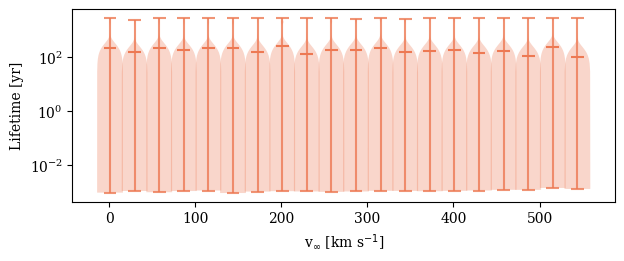

In [ ]:
mlist0 = ['lifetime']
mylabel0 = r'Lifetime [yr]'
plotobj.plot_metric_array_wrt_v(metric_list=mlist0, metric_ylabel=mylabel0, analysis_name='CygnusX1', save=False)

/data/a.saricaoglu/repo/captus/src/plotting/Plotting.py:410: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(frameon=False, loc='upper left', ncol=2)


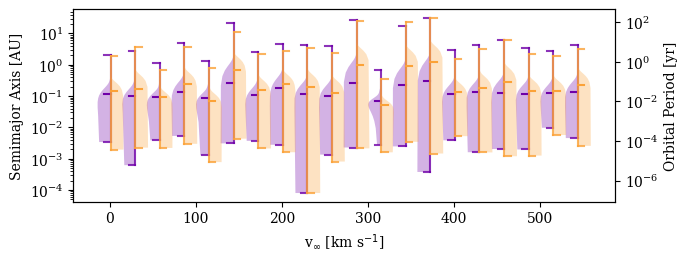

In [ ]:
plotobj = pl.Plots(name='cygnus_trial', analysis=[analysis])

mlist = [['semi_major_axes'], ['orbital_periods']]
mylabel = [r'Semimajor Axis [AU]', r'Orbital Period [yr]']
dataset = plotobj.plot_metric_array_wrt_v_twinaxis(metric_lists=mlist, metric_ylabels=mylabel, analysis_name='CygnusX1', save=False)

In [ ]:

s = datetime.datetime.now()
system_param_dict = configuration.get_system_param(all=True)
simulation_param_dict = configuration.get_simulation_param(all=True)
print(f'Simulation parameters: {simulation_param_dict}')
trials = simulation_param_dict['trials']
sample_size = simulation_param_dict['sample_size']
v_inf_grid = simulation_param_dict['v_inf_grid']
e_limits = simulation_param_dict['e_lim']

# def mc_worker(pars):
#     system_param_dict, child_ss, v_inf, trials, sample_size = pars
#     rng = Generator(PCG64(child_ss)) # independent per worker
#     simulation = mc_imp.MonteCarloSimulation(system_param_dict, rng)
#     simulation.set_importance_sampling(quota=sample_size)
#     return simulation.run_monte_carlo_simulation(trials, v_inf)

# if __name__ == "__main__":

#     base_ss = SeedSequence(seed)
#     child_sss = base_ss.spawn(len(v_inf_grid))
#     pars = [(system_param_dict, child_sss[i], v_inf_grid[i], trials, sample_size) for i in range(len(v_inf_grid))]
#     # Create a pool of workers
#     num_cores = len(v_inf_grid)  # Get the number of available CPU cores
#     with multiprocessing.Pool(processes=num_cores) as pool:
#         # Distribute the simulations across the cores
#         results = pool.map(mc_worker, pars)
#     pool.close()
#     pool.join()

#     print(f'Execution time: {datetime.datetime.now() - s} for {len(v_inf_grid)} simulations')

Simulation parameters: {'trials': 10000000, 'max_trials': 1000000000, 'sample_size': 200, 'max_e': 0.95, 'vDM': 220000.0, 'v_inf_grid': array([  1000.        ,  29578.94736842,  58157.89473684,  86736.84210526,
       115315.78947368, 143894.73684211, 172473.68421053, 201052.63157895,
       229631.57894737, 258210.52631579, 286789.47368421, 315368.42105263,
       343947.36842105, 372526.31578947, 401105.26315789, 429684.21052632,
       458263.15789474, 486842.10526316, 515421.05263158, 544000.        ]), 'importance_sampling': True}


KeyError: 'e_lim'

In [ ]:
# Read monte carlo results and plot
import pandas as pd
import glob
import os
save_dir = f'../runs/{name}/Monte_Carlo_Results/N1e+09'
print(f'Loading results from {save_dir}')
all_files = glob.glob(os.path.join(save_dir, "monte_carlo_results_*.npz"))
print(f'Found {len(all_files)} files')
v_dict = {}
for file in all_files:
    print(f'Loading {file}')
    data = np.load(file)
    key = int(data['v_inf']/1e3)  # convert to km/s for plotting
    print(f'v_inf = {key} km/s')
    v_dict[key] = data
print(v_dict)

Loading results from ../runs/CygnusX1/Monte_Carlo_Results/N1e+09
Found 20 files
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v29.6_s42.npz
v_inf = 29 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v115.3_s42.npz
v_inf = 115 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v58.2_s42.npz
v_inf = 58 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v86.7_s42.npz
v_inf = 86 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v172.5_s42.npz
v_inf = 172 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v143.9_s42.npz
v_inf = 143 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v1.0_s42.npz
v_inf = 1 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v229.6_s42.npz
v_inf = 229 km/s
Loading ../runs/CygnusX1/Monte_Carlo_Results/N1e+09/monte_carlo_results_v201.1_s42.npz
v_inf = 201

v_inf = 17 km/s: a_mean - sampled_a_mean = -0.196 au, a_std - sampled_a_std = -0.434 au
v_inf = 11 km/s: a_mean - sampled_a_mean = 1.307 au, a_std - sampled_a_std = 1.738 au
v_inf = 22 km/s: a_mean - sampled_a_mean = -0.935 au, a_std - sampled_a_std = -1.435 au
v_inf = 6 km/s: a_mean - sampled_a_mean = 2.585 au, a_std - sampled_a_std = 1.389 au
v_inf = 1 km/s: a_mean - sampled_a_mean = -1.616 au, a_std - sampled_a_std = 2.398 au

In [ ]:
# if 'rng' not in locals():
#     rng = np.random.default_rng(seed)

sampled_v_dict = {}
for v in v_dict.keys():
    data = v_dict[v]  # npz file handle
    n_captured = int(data['n_captured'])
    print(f'captured objects for v_inf = {v} km/s: {n_captured}')
    if n_captured == 0:
        continue

    # Arrays of per-capture parameters saved by MC
    a_au = data['a_au']            # shape (n_captured,)
    e_arr = data['e']              # shape (n_captured,)
    cap_lambda = data['cap_lambda']# shape (n_captured,)
    cap_beta = data['cap_beta']    # shape (n_captured,)
    cap_b = data['cap_b']          # shape (n_captured,) in meters
    cap_phi = data['cap_phi']      # shape (n_captured,)
    epsilon = data['epsilon']
    sampled = data['sample_number']

    # Sanity: all arrays must have length n_captured
    assert len(a_au) == len(e_arr) == len(cap_lambda) == len(cap_beta) == len(cap_b) == len(cap_phi) == n_captured

    # Choose indices
    if n_captured <= 200:
        idx = np.arange(n_captured)
    else:
        idx = rng.choice(n_captured, size=200, replace=False)

    # Slice consistently
    sampled_v_dict[v] = {
        'v_inf': float(data['v_inf']),             # m/s
        'a_au': a_au[idx],
        'e': e_arr[idx],
        'lambda1': cap_lambda[idx],
        'beta': cap_beta[idx],
        'b': cap_b[idx],                         # meters (convert in OrbitalSimulation)
        'phi': cap_phi[idx],
        'n_sampled': len(idx),
    }
    print(f'v_inf = {v} km/s: sampled {len(idx)} captured objects')


captured objects for v_inf = 1 km/s: 200
v_inf = 1 km/s: sampled 200 captured objects
captured objects for v_inf = 5 km/s: 200
v_inf = 5 km/s: sampled 200 captured objects
captured objects for v_inf = 9 km/s: 200
v_inf = 9 km/s: sampled 200 captured objects
captured objects for v_inf = 14 km/s: 200
v_inf = 14 km/s: sampled 200 captured objects
captured objects for v_inf = 18 km/s: 200
v_inf = 18 km/s: sampled 200 captured objects


In [ ]:

# def rebound_worker(pars):
#     system_param_dict, child_ss, i, v_inf, lambda1, beta, phi, b, a_c, e_c = pars
#     rng = Generator(PCG64(child_ss))  # independent per worker
#     simulation = OrbitalSimulation(system_param_dict, rng)
#     return simulation.run_orbital_integration(i, v_inf, lambda1, beta, phi, b, a_c, e_c)

# if __name__ == "__main__":
#     # Build a single flat list of tasks and run pool.map once.
#     num_cores = 30  # limit workers (or use multiprocessing.cpu_count())
#     total_jobs = np.sum([vdata['n_sampled'] for vdata in sampled_v_dict.values()])

#     base_ss = SeedSequence(seed)
#     child_sss = base_ss.spawn(int(total_jobs))  # one child seed per job

#     pars = []
#     job_idx = 0
#     for j, (v_key, vdata) in enumerate(sampled_v_dict.items()):
#         v_inf = vdata['v_inf']
#         lambda1 = vdata['lambda1']
#         beta = vdata['beta']
#         b = vdata['b']
#         phi = vdata['phi']
#         a_c = vdata['a_au']
#         e_c = vdata['e']

#         # Create a task per sampled capture for this v_inf
#         for i in range(vdata['n_sampled']):
#             pars.append((
#                 system_param_dict,
#                 child_sss[job_idx],  # simple monotonic index across all jobs
#                 i, v_inf, lambda1[i], beta[i], phi[i], b[i], a_c[i], e_c[i]
#             ))
#             job_idx += 1

#     # Dispatch all jobs once, avoid pool inside the loop
#     with multiprocessing.Pool(processes=num_cores) as pool:
#         results = pool.map(rebound_worker, pars)

#     print(f'Execution time: {datetime.datetime.now() - s} for {job_idx} simulations')

Simulation 9 of starting at 2025-12-24 19:37:04.951155Simulation 0 of starting at 2025-12-24 19:37:04.951091Simulation 36 of starting at 2025-12-24 19:37:04.951866Simulation 18 of starting at 2025-12-24 19:37:04.951685Simulation 27 of starting at 2025-12-24 19:37:04.951803Simulation 45 of starting at 2025-12-24 19:37:04.952231Simulation 72 of starting at 2025-12-24 19:37:04.952266Simulation 63 of starting at 2025-12-24 19:37:04.952380Simulation 54 of starting at 2025-12-24 19:37:04.952481Simulation 81 of starting at 2025-12-24 19:37:04.952938Simulation 108 of starting at 2025-12-24 19:37:04.953086Simulation 90 of starting at 2025-12-24 19:37:04.952975


Simulation 99 of starting at 2025-12-24 19:37:04.953169Simulation 117 of starting at 2025-12-24 19:37:04.953147



Simulation 153 of starting at 2025-12-24 19:37:04.953661
Simulation 144 of starting at 2025-12-24 19:37:04.953750


Simulation 180 of starting at 2025-12-24 19:37:04.954359Simulation 198 of starting at 2025-12-24 19:37:04.9

Process ForkPoolWorker-1:


KeyboardInterrupt: 

In [3]:
name = 'Sun_Jupiter_lightPBH_impsamp_vinfmax'

In [4]:
# ...existing code...
import os, glob, numpy as np

base_dir = f"/data/a.saricaoglu/repo/captus/runs/{name}/Rebound_Simulation_Results"
mc_dir   = f"/data/a.saricaoglu/repo/captus/runs/{name}/Monte_Carlo_Results/N1e+09"
os.makedirs(f"../plots/{name}", exist_ok=True)
def vkey_from_vinf(v_inf_mps: float) -> str:
    # km/s rounded to nearest integer, prefixed with 'v'
    return f"v{int(np.rint(v_inf_mps/1e3))}"

# 1) Index MC files by vX
mc_by_vkey = {}
for mc_path in glob.glob(os.path.join(mc_dir, "monte_carlo_results_*.npz")):
    try:
        with np.load(mc_path, allow_pickle=True) as mc_probe:
            v_inf = float(mc_probe["v_inf"])
        vk = vkey_from_vinf(v_inf)
        # keep the handle open for later reads (consistent with rest of notebook)
        mc_by_vkey[vk] = {
            "path": mc_path,
            "v_key": vk,
            "v_inf": v_inf,
            "data": np.load(mc_path, allow_pickle=True),
        }
    except Exception as e:
        print(f"Failed to index MC {mc_path}: {e}")

# 2) Index Rebound Simulation files by vX subfolder
rebound_by_vkey = {}
for v_folder in sorted(os.listdir(base_dir)):
    if not (v_folder.startswith("v") and os.path.isdir(os.path.join(base_dir, v_folder))):
        continue
    v_path = os.path.join(base_dir, v_folder)
    entries = []

    for f in sorted(glob.glob(os.path.join(v_path, "*.npz"))):
        try:
            data = np.load(f, allow_pickle=True)
            sys_id = int(data["i"]) if "i" in data.files else os.path.splitext(os.path.basename(f))[0]
            entries.append({
                "path": f,
                "i": sys_id,
                "data": data,
            })
        except Exception as e:
            print(f"Failed to load Rebound {f}: {e}")
    rebound_by_vkey[v_folder] = entries

# 3) Combine into a single catalog keyed by vX (union of keys)
all_keys = sorted(set(mc_by_vkey.keys()) | set(rebound_by_vkey.keys()))
catalog = {}
for vk in all_keys:
    catalog[vk] = {
        "mc": mc_by_vkey.get(vk),                # dict or None
        "rebound": rebound_by_vkey.get(vk, []),  # list (possibly empty)
    }

print("Catalog summary:")
for k in all_keys:
    mc_ok = "yes" if catalog[k]["mc"] else "no"
    n_rb = len(catalog[k]["rebound"])
    print(f"  {k}: MC={mc_ok}, Rebound files={n_rb}")
# ...existing code...

Catalog summary:
  v1: MC=yes, Rebound files=200
  v10: MC=yes, Rebound files=200
  v14: MC=yes, Rebound files=200
  v19: MC=yes, Rebound files=200
  v23: MC=yes, Rebound files=200
  v27: MC=yes, Rebound files=200
  v32: MC=yes, Rebound files=200
  v36: MC=yes, Rebound files=193
  v40: MC=yes, Rebound files=0
  v5: MC=yes, Rebound files=200


In [6]:
import numpy as np
from astropy import units as u
vdm = (220*u.km/u.s).to(u.au/u.yr).value  # m/s
for v in catalog.keys():
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    # Skip if no MC data
    if mc_data is None:
        continue
    print(f"Start info for {v}:")
    start_info = [orbsim_data["data"]["start_info"] for orbsim_data in catalog[v]["rebound"] if "start_info" in orbsim_data["data"].files]
    start_distances = [orbsim_data["data"]["start_distances"] for orbsim_data in catalog[v]["rebound"] if "start_distances" in orbsim_data["data"].files]
    errors = [orbsim_data["data"]["errors"] for orbsim_data in catalog[v]["rebound"] if "errors" in orbsim_data["data"].files]
    flags = [orbsim_data["data"]["termination_flag"] for orbsim_data in catalog[v]["rebound"] if "termination_flag" in orbsim_data["data"].files]
    lifetimes = [orbsim_data["data"]["lifetime"] for orbsim_data in catalog[v]["rebound"] if "lifetime" in orbsim_data["data"].files]
    b_err_count = 0
    P_err_count = 0
    time_err_count = 0
    escape_C_count = 0
    escape_B_count = 0
    energy_err_count = 0
    preprocess_err_count = 0
    time_exceeded_count = 0
    collision_count = 0
    ej_mask = []
    coll_mask = []
    for idx, (sinfo, sdist, err, flag, lifetime) in enumerate(zip(start_info, start_distances, errors, flags, lifetimes)):
        # print(f"  Simulation {idx}: start_info={sinfo}")
        # print(f"  Simulation {idx}: start_distances={sdist}")

        if len(err) > 0:

            if 'impact parameter b' in err[0]:
                b_err_count += 1
                
            if 'period' in err[0]:
                P_err_count += 1
                # print(f"  Simulation {idx}: errors={err}")
                # print(f"  Simulation {idx}: start_info={sinfo}")
            if 'time' in err[0]:
                time_err_count += 1

            if flag == None:
                preprocess_err_count += 1
                coll_mask.append(0)
        else:
            if flag == None:
                collision_count += 1
                coll_mask.append(1)
            else:
                coll_mask.append(0)
   
        if 'escape_C' in flag:
            escape_C_count += 1
            ej_mask.append(1)
        else:
            ej_mask.append(0)
            
        if 'escape_B' in flag:
            escape_B_count += 1
        if 'energy' in flag:
            energy_err_count += 1

        if 'time_exceeded' in flag:
            time_exceeded_count += 1

    catalog[v]['termination_flags'] = {
        "b_err_count": b_err_count,
        "P_err_count": P_err_count,
        "time_err_count": time_err_count,
        "escape_C_count": escape_C_count,
        "escape_B_count": escape_B_count,
        "energy_err_count": energy_err_count,
        "preprocess_err_count": preprocess_err_count,
        "time_exceeded_count": time_exceeded_count,
        "collision_count": collision_count,
    }
    catalog[v]['ej_mask'] = ej_mask
    catalog[v]['coll_mask'] = coll_mask
    
    print(f"Total simulations for {v} with impact parameter b errors: {b_err_count}")
    print(f"Total simulations for {v} with period errors: {P_err_count}")
    print(f"Total simulations for {v} with time errors: {time_err_count}")
    print(f"Total simulations for {v} with escape C flag: {escape_C_count}")
    print(f"Total simulations for {v} with escape B flag: {escape_B_count}")
    print(f"Total simulations for {v} with energy flag: {energy_err_count}")
    print(f"Total simulations for {v} with preprocess errors: {preprocess_err_count}")
    print(f"Total simulations for {v} with time exceeded flags: {time_exceeded_count}")
    print(f"Total simulations for {v} with collision flags: {collision_count}")

Start info for v1:
Total simulations for v1 with impact parameter b errors: 0
Total simulations for v1 with period errors: 0
Total simulations for v1 with time errors: 0
Total simulations for v1 with escape C flag: 200
Total simulations for v1 with escape B flag: 0
Total simulations for v1 with energy flag: 0
Total simulations for v1 with preprocess errors: 0
Total simulations for v1 with time exceeded flags: 0
Total simulations for v1 with collision flags: 0
Start info for v10:
Total simulations for v10 with impact parameter b errors: 0
Total simulations for v10 with period errors: 0
Total simulations for v10 with time errors: 0
Total simulations for v10 with escape C flag: 200
Total simulations for v10 with escape B flag: 0
Total simulations for v10 with energy flag: 0
Total simulations for v10 with preprocess errors: 0
Total simulations for v10 with time exceeded flags: 0
Total simulations for v10 with collision flags: 0
Start info for v14:
Total simulations for v14 with impact para

In [ ]:
occurrences = {}
for v in catalog.keys():
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    ej_mask = catalog[v]['ej_mask']
    print(f'ejected C count for {v}: {np.sum(ej_mask)}')
    coll_mask = catalog[v]['coll_mask']
    print(f'collision count for {v}: {np.sum(coll_mask)}')
    preprocess_err_count = catalog[v]['termination_flags']['preprocess_err_count']
    print(f'preprocess error count for {v}: {preprocess_err_count}')
    time_exceeded_count = catalog[v]['termination_flags']['time_exceeded_count']
    print(f'time exceeded count for {v}: {time_exceeded_count}')
    print(orbsim_data)
    # Skip if no MC data
    if mc_data is None:
        continue

    vinfinity = (mc_data["v_inf"]*u.m/u.s).to(u.au/u.yr).value
    mc_pkg = mc_data["data"]
    n_captured = int(mc_pkg["n_captured"])
    capture_cross_section = (mc_pkg["sigma_MC_m2"] * u.m**2).to(u.au**2).value
    lifetimes = [e["data"]["lifetime"] for e in orbsim_data if "lifetime" in e["data"].files]
    ejected_lifetimes = [l for l, ej in zip(lifetimes, ej_mask) if ej == 1]
    collided_lifetimes = [l for l, coll in zip(lifetimes, coll_mask) if coll == 1]

    ejection_rate = len([l for l in ejected_lifetimes if l is not None]) / np.sum([l for l in ejected_lifetimes if l is not None])
    collision_rate = len([l for l in collided_lifetimes if l is not None]) / np.sum([l for l in collided_lifetimes if l is not None])
    termination_rate = ejection_rate + collision_rate  # total removal rate
    f_approx = (np.sqrt(2/np.pi)) * (vinfinity**2 / (vdm**3)) * np.exp(- (vinfinity)**2/(2*vdm**2))
    print(f'v_inf = {mc_pkg["v_inf"]/1e3} km/s: captured = {n_captured}, capture cross-section = {capture_cross_section:.3e} au^2, ejection rate = {ejection_rate:.3e} 1/Myr')
    total_rate = len(lifetimes) / np.sum(lifetimes )

    rClose = calc.r_close(epsilon, mA, mB, aB)
    v1Mag = calc.v_1_mag(mc_data["v_inf"], muA, muB, aB, rClose)
    v1Mag_au = v1Mag * (u.m / u.s).to(u.au/u.yr) # convert to au/yr

    n_eq_ejection = f_approx * capture_cross_section * v1Mag_au / ejection_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s: {n_eq_ejection:.3e}')
    n_eq_collision = f_approx * capture_cross_section * v1Mag_au / collision_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s (collision): {n_eq_collision:.3e}')
    n_eq = f_approx * capture_cross_section * v1Mag_au / termination_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s (total): {n_eq:.3e}')
    n_eq_total = f_approx * capture_cross_section * v1Mag_au / total_rate  # captures per au
    occurrences[v] = {
        "n_captured": n_captured,
        "capture_cross_section_au": capture_cross_section,
        "capture_cross_section_areaB": mc_pkg["sigma_MC_areaB"],
        "ejection_rate_1_per_yr": ejection_rate,
        "collision_rate_1_per_yr": collision_rate,
        "termination_rate_1_per_yr": termination_rate,
        "total_rate_1_per_yr": total_rate,
        "total_systems_in_equilibrium": n_eq,
        "ejected_systems_in_equilibrium": n_eq_ejection,
        "collided_systems_in_equilibrium": n_eq_collision,
        "total_systems_in_equilibrium_all_removals": n_eq_total,

    }


KeyError: 'ej_mask'

In [ ]:
N_eq = sum([occurrences[v]['estimated_captures'] for v in occurrences.keys() if occurrences[v]['estimated_captures'] > 0])
print(f'Total estimated captures across all v_inf: {N_eq:.3e} au^3')


Total estimated captures across all v_inf: 1.545e-01 au^3


In [ ]:
Neq1 = 9.981e-02
Neq0 = 1.003e-01
print(f'Ratio N_eq2 / N_eq1: {N_eq / Neq1:.3e}')
print(f'Ratio N_eq2 / N_eq0: {N_eq / Neq0:.3e}')
print(f'Ratio N_eq0 / N_eq1: {Neq0 / Neq1:.3e}')


Ratio N_eq2 / N_eq1: 1.548e+00
Ratio N_eq2 / N_eq0: 1.541e+00
Ratio N_eq0 / N_eq1: 1.005e+00


Lehmann 2021, below eq 32: N_eq = 0.1 au^3 * n_inf 
where n_inf is number densiity at infinity

[{'path': '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_0_42.npz', 'i': 0, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_0_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_100_42.npz', 'i': 100, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_100_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_101_42.npz', 'i': 101, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_101_42.npz' with keys: i, v_inf, start_info, errors, start_distan

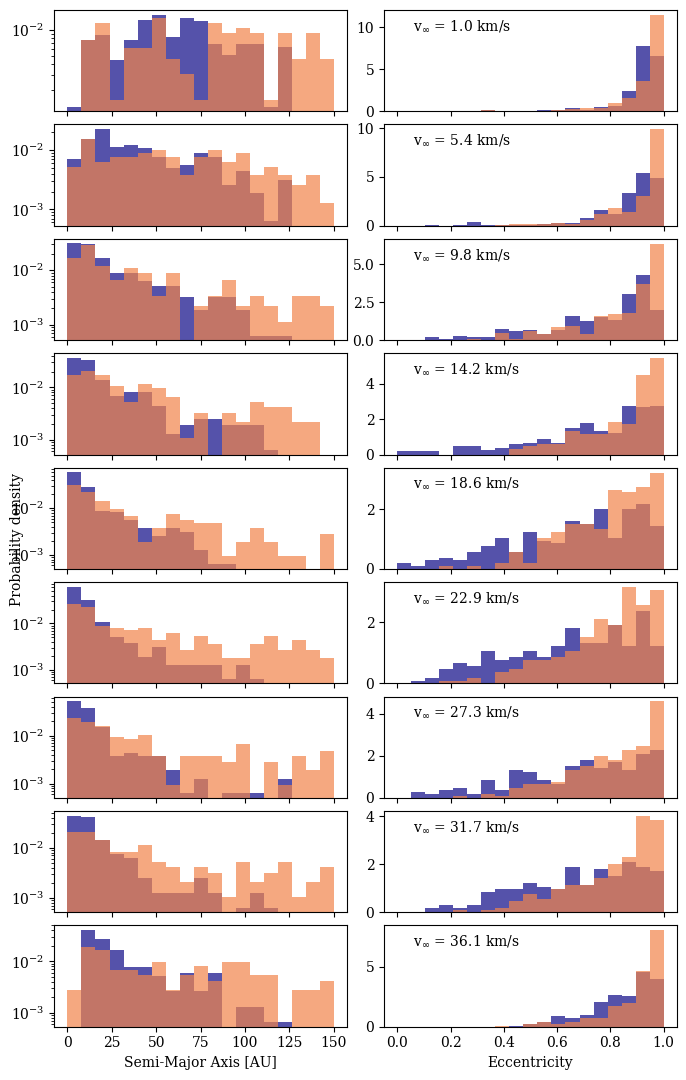

In [ ]:
colors_plasma = plt.get_cmap('plasma', len(catalog.keys()) + 1)
fig, ax = plt.subplots(9, 2, figsize=(7, 10.9), sharex='col')
# plotting histograms from the catalog
i = 0
sorted_catalog_keys = sorted(catalog.keys(), key=lambda x: int(x[1:]))  # sort by v_inf value
for v in sorted_catalog_keys:
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    print(orbsim_data)
    n_captured = mc_data["data"]['n_captured'] if mc_data is not None else 0
    # Skip if no MC data
    if n_captured == 0:
        continue

     # Arrays of per-capture parameters saved by MC

    a_mc_au = mc_data["data"]['a_au']
    e_mc = mc_data["data"]['e']

    a_mean_rebound = []
    e_mean_rebound = []
    for entry in orbsim_data:
        data = entry["data"]
        if "semi_major_axes" in data.files and "eccentricities" in data.files:
            a_mean_rebound.append(np.mean(data["semi_major_axes"]))
            e_mean_rebound.append(np.mean(data["eccentricities"]))
    a_mean_rebound = np.array(a_mean_rebound)
    e_mean_rebound = np.array(e_mean_rebound)

    plt.rcParams.update({'font.family': 'serif'})

    
    bins_a = np.linspace(0, 150, 20)
    bins_e = np.linspace(0, 1, 20)
    ax[i][0].hist(a_mc_au, bins=bins_a, alpha=0.7, density=True, color=colors_plasma(0))
    ax[i][0].hist(a_mean_rebound, bins=bins_a, alpha=0.7, density=True, color=colors_plasma(7))
    ax[i][1].text(0.1, 0.8, fr'v$_\infty$ = {mc_data["v_inf"]/1e3:.1f} km/s', transform=ax[i][1].transAxes)
    ax[i][1].hist(e_mc, bins=bins_e, alpha=0.7, density=True, color=colors_plasma(0))
    ax[i][1].hist(e_mean_rebound, bins=bins_e, alpha=0.7, density=True, color=colors_plasma(7))
    # ax[i][0].set_xlabel('Semi-Major Axis (a) [AU]')
    # ax[0].set_ylabel('Probability density')
    ax[i][0].set_yscale('log')
    # ax[i][1].set_xlabel('Eccentricity (e)')
    # ax[1].set_ylabel('Probability density')
    # ax[i][1].set_yscale('log')
    i += 1
ax[i-1][0].set_xlabel('Semi-Major Axis [AU]')
ax[i-1][1].set_xlabel('Eccentricity')
fig.tight_layout(h_pad=.15, w_pad=0.4, )
fig.text(0.02, 0.5, 'Probability density', va='center', rotation='vertical')

plt.savefig(f'../plots/{name}/Comparison_MC_Rebound_SemiMajorAxis_Eccentricity.png', dpi=300)
plt.show()

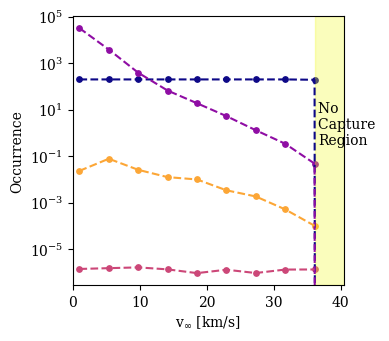

In [ ]:
# plot occurences per v_inf  
fig, ax = plt.subplots(figsize=(3.5, 3.5))
n_caps = []
capture_cross_sections = []
ejection_rates = []
estimated_captures_array = []
v_inf_kms_list = []
for v in occurrences.keys():
    v_inf_kms = catalog[v]["mc"]["v_inf"] / 1e3  # km/s
    n_captured = occurrences[v]['n_captured']
    capture_cross_section = occurrences[v]['capture_cross_section_areaB']
    ejection_rate = occurrences[v]['ejection_rate_1_per_yr']
    estimated_captures = occurrences[v]['estimated_captures']
    v_inf_kms_list.append(v_inf_kms)
    capture_cross_sections.append(capture_cross_section)
    n_caps.append(n_captured)
    ejection_rates.append(ejection_rate)
    estimated_captures_array.append(estimated_captures)
    ax.scatter(v_inf_kms, n_captured, label='Number Captured', color=colors_plasma(0), s=15)
    ax.scatter(v_inf_kms, capture_cross_section, label=r'Capture Cross-Section (Area$_B$)', color=colors_plasma(3), s=15)
    ax.scatter(v_inf_kms, ejection_rate, label='Ejection Rate (1/yr)', color=colors_plasma(5), s=15)
    ax.scatter(v_inf_kms, estimated_captures, label='Estimated Captures', color=colors_plasma(8), s=15)
v_inf_kms_array = np.array(v_inf_kms_list)
n_caps_array = np.array(n_caps)
capture_cross_sections_array = np.array(capture_cross_sections)
ejection_rates_array = np.array(ejection_rates)
estimated_captures_array = np.array(estimated_captures_array)
# Sort for plotting lines
sorted_indices = np.argsort(v_inf_kms_array)
ax.plot(v_inf_kms_array[sorted_indices], n_caps_array[sorted_indices], color=colors_plasma(0), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], capture_cross_sections_array[sorted_indices], color=colors_plasma(3), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], ejection_rates_array[sorted_indices], color=colors_plasma(5), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], estimated_captures_array[sorted_indices], color=colors_plasma(8), linestyle='--')
ax.set_xlabel(r'v$_\infty$ [km/s]')
ax.set_xlim(0, np.max(v_inf_kms_array))
ax.set_yscale('log')
ax.set_ylabel('Occurrence')
# Shade after the last v_inf that has rates to the end of the plot
xmax = ax.get_xlim()[1]
mask = np.isfinite(ejection_rates_array) & (ejection_rates_array > 0)
if np.any(mask):
    x_last = np.max(v_inf_kms_array[mask])
else:
    x_last = np.max(v_inf_kms_array)
ax.axvspan(x_last, xmax, color=colors_plasma(10), alpha=0.3)
ax.text(x_last + 0.11*(xmax - x_last), 0.3, 'No \nCapture \nRegion', color='black', alpha=1 )
# ax.legend()
plt.savefig(f'../plots/{name}/Occurrences_Rates_vs_vinf.png', dpi=300)
plt.show()


In [10]:
print(name)

Sun_Jupiter_lightPBH_impsamp_vinfmax


In [11]:
# ...existing code...
import os, glob, numpy as np

base_dir = f"/data/a.saricaoglu/repo/captus/runs/{name}/Rebound_Simulation_Results"
mc_dir   = f"/data/a.saricaoglu/repo/captus/runs/{name}/Monte_Carlo_Results/N1e+09"
os.makedirs(f"../plots/{name}", exist_ok=True)
def vkey_from_vinf(v_inf_mps: float) -> str:
    # km/s rounded to nearest integer, prefixed with 'v'
    return f"v{int(np.rint(v_inf_mps/1e3))}"

# 1) Index MC files by vX
mc_by_vkey = {}
for mc_path in glob.glob(os.path.join(mc_dir, "monte_carlo_results_*.npz")):
    try:
        with np.load(mc_path, allow_pickle=True) as mc_probe:
            v_inf = float(mc_probe["v_inf"])
        vk = vkey_from_vinf(v_inf)
        # keep the handle open for later reads (consistent with rest of notebook)
        mc_by_vkey[vk] = {
            "path": mc_path,
            "v_key": vk,
            "v_inf": v_inf,
            "data": np.load(mc_path, allow_pickle=True),
        }
    except Exception as e:
        print(f"Failed to index MC {mc_path}: {e}")

# 2) Index Rebound Simulation files by vX subfolder
rebound_by_vkey = {}
for v_folder in sorted(os.listdir(base_dir)):
    if not (v_folder.startswith("v") and os.path.isdir(os.path.join(base_dir, v_folder))):
        continue
    v_path = os.path.join(base_dir, v_folder)
    entries = []

    for f in sorted(glob.glob(os.path.join(v_path, "*.npz"))):
        try:
            data = np.load(f, allow_pickle=True)
            sys_id = int(data["i"]) if "i" in data.files else os.path.splitext(os.path.basename(f))[0]
            entries.append({
                "path": f,
                "i": sys_id,
                "data": data,
            })
        except Exception as e:
            print(f"Failed to load Rebound {f}: {e}")
    rebound_by_vkey[v_folder] = entries

# 3) Combine into a single catalog keyed by vX (union of keys)
all_keys = sorted(set(mc_by_vkey.keys()) | set(rebound_by_vkey.keys()))
catalog = {}
for vk in all_keys:
    catalog[vk] = {
        "mc": mc_by_vkey.get(vk),                # dict or None
        "rebound": rebound_by_vkey.get(vk, []),  # list (possibly empty)
    }

print("Catalog summary:")
for k in all_keys:
    mc_ok = "yes" if catalog[k]["mc"] else "no"
    n_rb = len(catalog[k]["rebound"])
    print(f"  {k}: MC={mc_ok}, Rebound files={n_rb}")

# Optional convenience views:
per_v_semi_major_axes = {
    k: [e["data"]["semi_major_axes"] for e in catalog[k]["rebound"] if "semi_major_axes" in e["data"].files]
    for k in catalog.keys()
}
per_v_lifetimes = {
    k: [e["data"]["lifetime"] for e in catalog[k]["rebound"] if "lifetime" in e["data"].files]
    for k in catalog.keys()
}
# ...existing code...

Catalog summary:
  v1: MC=yes, Rebound files=200
  v10: MC=yes, Rebound files=200
  v14: MC=yes, Rebound files=200
  v19: MC=yes, Rebound files=200
  v23: MC=yes, Rebound files=200
  v27: MC=yes, Rebound files=200
  v32: MC=yes, Rebound files=200
  v36: MC=yes, Rebound files=193
  v40: MC=yes, Rebound files=0
  v5: MC=yes, Rebound files=200


In [12]:
vdm = (220*u.km/u.s).to(u.au/u.yr).value  # m/s
print(f"Model: {name}")
termination_flags = {}
sorted_catalog_keys = sorted(catalog.keys(), key=lambda x: int(x[1:]))  # sort by v_inf value
for v in sorted_catalog_keys:
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    # Skip if no MC data
    if mc_data is None:
        continue
    print(f"Start info for {v}:")
    start_info = [orbsim_data["data"]["start_info"] for orbsim_data in catalog[v]["rebound"] if "start_info" in orbsim_data["data"].files]
    start_distances = [orbsim_data["data"]["start_distances"] for orbsim_data in catalog[v]["rebound"] if "start_distances" in orbsim_data["data"].files]
    errors = [orbsim_data["data"]["errors"] for orbsim_data in catalog[v]["rebound"] if "errors" in orbsim_data["data"].files]
    flags = [orbsim_data["data"]["termination_flag"] for orbsim_data in catalog[v]["rebound"] if "termination_flag" in orbsim_data["data"].files]
    lifetimes = [orbsim_data["data"]["lifetime"] for orbsim_data in catalog[v]["rebound"] if "lifetime" in orbsim_data["data"].files]
    b_err_count = 0
    P_err_count = 0
    time_err_count = 0
    escape_C_count = 0
    escape_B_count = 0
    energy_err_count = 0
    preprocess_err_count = 0
    time_exceeded_count = 0
    collision_count = 0
    ej_mask = []
    coll_mask = []
    for idx, (sinfo, sdist, err, flag, lifetime) in enumerate(zip(start_info, start_distances, errors, flags, lifetimes)):
        # print(f"  Simulation {idx}: start_info={sinfo}")
        # print(f"  Simulation {idx}: start_distances={sdist}")

        if len(err) > 0:

            if 'impact parameter b' in err[0]:
                b_err_count += 1
                
            if 'period' in err[0]:
                P_err_count += 1
                # print(f"  Simulation {idx}: errors={err}")
                # print(f"  Simulation {idx}: start_info={sinfo}")
            if 'time' in err[0]:
                time_err_count += 1

            if flag == None:
                preprocess_err_count += 1
                coll_mask.append(0)
        else:
            if flag == None:
                collision_count += 1
                coll_mask.append(1)
            else:
                coll_mask.append(0)
   
        if 'escape_C' in flag:
            escape_C_count += 1
            ej_mask.append(1)
        else:
            ej_mask.append(0)
            
        if 'escape_B' in flag:
            escape_B_count += 1
        if 'energy' in flag:
            energy_err_count += 1

        if 'time_exceeded' in flag:
            time_exceeded_count += 1

    catalog[v]['termination_flags'] = {
        "b_err_count": b_err_count,
        "P_err_count": P_err_count,
        "time_err_count": time_err_count,
        "escape_C_count": escape_C_count,
        "escape_B_count": escape_B_count,
        "energy_err_count": energy_err_count,
        "preprocess_err_count": preprocess_err_count,
        "time_exceeded_count": time_exceeded_count,
        "collision_count": collision_count,
    }
    catalog[v]['ej_mask'] = ej_mask
    catalog[v]['coll_mask'] = coll_mask
    
    print(f"impact parameter b errors: {b_err_count}")
    print(f"period errors: {P_err_count}")
    print(f"time errors: {time_err_count}")
    print(f"escape C flag: {escape_C_count}")
    print(f"escape B flag: {escape_B_count}")
    print(f"energy flag: {energy_err_count}")
    print(f"preprocess errors: {preprocess_err_count}")
    print(f"time exceeded flags: {time_exceeded_count}")
    print(f"collision flags: {collision_count}")
    print("-----------------------------------")

Model: Sun_Jupiter_lightPBH_impsamp_vinfmax
Start info for v1:
impact parameter b errors: 0
period errors: 0
time errors: 0
escape C flag: 200
escape B flag: 0
energy flag: 0
preprocess errors: 0
time exceeded flags: 0
collision flags: 0
-----------------------------------
Start info for v5:
impact parameter b errors: 0
period errors: 0
time errors: 0
escape C flag: 199
escape B flag: 0
energy flag: 0
preprocess errors: 0
time exceeded flags: 0
collision flags: 1
-----------------------------------
Start info for v10:
impact parameter b errors: 0
period errors: 0
time errors: 0
escape C flag: 200
escape B flag: 0
energy flag: 0
preprocess errors: 0
time exceeded flags: 0
collision flags: 0
-----------------------------------
Start info for v14:
impact parameter b errors: 2
period errors: 0
time errors: 0
escape C flag: 197
escape B flag: 1
energy flag: 0
preprocess errors: 0
time exceeded flags: 0
collision flags: 2
-----------------------------------
Start info for v19:
impact paramet

In [13]:
occurrences = {}
for v in catalog.keys():
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    ej_mask = catalog[v]['ej_mask']
    print(f'ejected C count for {v}: {np.sum(ej_mask)}')
    coll_mask = catalog[v]['coll_mask']
    print(f'collision count for {v}: {np.sum(coll_mask)}')
    preprocess_err_count = catalog[v]['termination_flags']['preprocess_err_count']
    print(f'preprocess error count for {v}: {preprocess_err_count}')
    time_exceeded_count = catalog[v]['termination_flags']['time_exceeded_count']
    print(f'time exceeded count for {v}: {time_exceeded_count}')
    print(orbsim_data)
    # Skip if no MC data
    if mc_data is None:
        continue

    vinfinity = (mc_data["v_inf"]*u.m/u.s).to(u.au/u.yr).value
    mc_pkg = mc_data["data"]
    n_captured = int(mc_pkg["n_captured"])
    capture_cross_section = (mc_pkg["sigma_MC_m2"] * u.m**2).to(u.au**2).value
    lifetimes = [e["data"]["lifetime"] for e in orbsim_data if "lifetime" in e["data"].files]
    ejected_lifetimes = [l for l, ej in zip(lifetimes, ej_mask) if ej == 1]
    collided_lifetimes = [l for l, coll in zip(lifetimes, coll_mask) if coll == 1]

    ejection_rate = len([l for l in ejected_lifetimes if l is not None]) / np.sum([l for l in ejected_lifetimes if l is not None])
    collision_rate = len([l for l in collided_lifetimes if l is not None]) / np.sum([l for l in collided_lifetimes if l is not None])
    termination_rate = ejection_rate + collision_rate  # total removal rate
    f_approx = (np.sqrt(2/np.pi)) * (vinfinity**2 / (vdm**3)) * np.exp(- (vinfinity)**2/(2*vdm**2))
    print(f'v_inf = {mc_pkg["v_inf"]/1e3} km/s: captured = {n_captured}, capture cross-section = {capture_cross_section:.3e} au^2, ejection rate = {ejection_rate:.3e} 1/Myr')
    total_rate = len(lifetimes) / np.sum(lifetimes )

    rClose = calc.r_close(epsilon, mA, mB, aB)
    v1Mag = calc.v_1_mag(mc_data["v_inf"], muA, muB, aB, rClose)
    v1Mag_au = v1Mag * (u.m / u.s).to(u.au/u.yr) # convert to au/yr

    n_eq_ejection = f_approx * capture_cross_section * v1Mag_au / ejection_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s: {n_eq_ejection:.3e}')
    n_eq_collision = f_approx * capture_cross_section * v1Mag_au / collision_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s (collision): {n_eq_collision:.3e}')
    n_eq = f_approx * capture_cross_section * v1Mag_au / termination_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s (total): {n_eq:.3e}')
    n_eq_total = f_approx * capture_cross_section * v1Mag_au / total_rate  # captures per au
    occurrences[v] = {
        "n_captured": n_captured,
        "capture_cross_section_au": capture_cross_section,
        "capture_cross_section_areaB": mc_pkg["sigma_MC_areaB"],
        "ejection_rate_1_per_yr": ejection_rate,
        "collision_rate_1_per_yr": collision_rate,
        "termination_rate_1_per_yr": termination_rate,
        "total_rate_1_per_yr": total_rate,
        "total_systems_in_equilibrium": n_eq,
        "ejected_systems_in_equilibrium": n_eq_ejection,
        "collided_systems_in_equilibrium": n_eq_collision,
        "total_systems_in_equilibrium_all_removals": n_eq_total,

    }


ejected C count for v1: 200
collision count for v1: 0
preprocess error count for v1: 0
time exceeded count for v1: 0
[{'path': '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_0_42.npz', 'i': 0, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_0_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_100_42.npz', 'i': 100, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_100_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPBH_impsamp_vinfmax/Rebound_Simulation_Results/v1/sim_101_42.npz', 'i': 101, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_lightPB

/tmp/ipykernel_3682857/3446881873.py:27: RuntimeWarning: invalid value encountered in scalar divide
  collision_rate = len([l for l in collided_lifetimes if l is not None]) / np.sum([l for l in collided_lifetimes if l is not None])
/tmp/ipykernel_3682857/3446881873.py:26: RuntimeWarning: invalid value encountered in scalar divide
  ejection_rate = len([l for l in ejected_lifetimes if l is not None]) / np.sum([l for l in ejected_lifetimes if l is not None])
/tmp/ipykernel_3682857/3446881873.py:31: RuntimeWarning: invalid value encountered in scalar divide
  total_rate = len(lifetimes) / np.sum(lifetimes )


In [14]:
n_eq_ejection = sum([occurrences[v]['ejected_systems_in_equilibrium'] for v in occurrences.keys() if occurrences[v]['ejected_systems_in_equilibrium'] > 0])
n_eq_collision = sum([occurrences[v]['collided_systems_in_equilibrium'] for v in occurrences.keys() if occurrences[v]['collided_systems_in_equilibrium'] > 0])
n_eq_termination = sum([occurrences[v]['total_systems_in_equilibrium'] for v in occurrences.keys() if occurrences[v]['total_systems_in_equilibrium'] > 0])
n_eq_total = sum([occurrences[v]['total_systems_in_equilibrium_all_removals'] for v in occurrences.keys() if occurrences[v]['total_systems_in_equilibrium_all_removals'] > 0])
print(f'Total estimated number of captured PBHs in equilibrium ')
print(f'(ejection only): {n_eq_ejection:.3e}')
print(f'(collision only): {n_eq_collision:.3e}')
print(f'(total): {n_eq_termination:.3e}')
print(f'(all removals): {n_eq_total:.3e}')

Total estimated number of captured PBHs in equilibrium 
(ejection only): 1.840e-01
(collision only): 2.067e-01
(total): 3.574e-02
(all removals): 1.874e-01


Total estimated number of captured PBHs in equilibrium 
(ejection only): 1.510e-01
(collision only): 1.853e-01
(total): 1.818e-02
(all removals): 1.545e-01